# ZARA Sales Data Analysis

## Objective
This project analyzes ZARA product-level data to understand:
- Sales performance across categories
- Impact of promotions on sales
- Pricing trends and demand patterns
- High-performing products and segments

The insights can help retail teams improve pricing strategies, inventory planning,
and promotional effectiveness.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")


In [3]:
zara = pd.read_csv("zara.csv", sep=";")


In [4]:
zara.head()


,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


In [5]:
zara.tail()


,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
247,159182,Front of Store,Yes,Clothing,No,1014,Zara,https://www.zara.com/us/en/basic-100-wool-swea...,321993245-500-2,FAUX LEATHER OVERSIZED JACKET LIMITED EDITION,Jacket made of technical fabric with padded in...,169.00,USD,2024-02-19T09:10:43.883037,jackets,MAN
248,199233,Aisle,Yes,Clothing,No,2222,Zara,https://www.zara.com/us/en/colorblock-knit-cro...,330590505-500-2,CONTRASTING PATCHES BOMBER JACKET,Oversized jacket. Notched lapel collar and lon...,159.00,USD,2024-02-19T09:10:44.463883,jackets,MAN
249,137044,Aisle,No,Clothing,Yes,2534,Zara,https://www.zara.com/us/en/hooded-technical-ja...,320680326-107-39,PATCH BOMBER JACKET,Varsity jacket with elastic collar and long sl...,12.99,USD,2024-02-19T09:10:45.009106,jackets,MAN
250,154736,Front of Store,Yes,Clothing,Yes,1466,Zara,https://www.zara.com/us/en/houndstooth-suit-ja...,311292244-800-39,CROPPED BOMBER JACKET LIMITED EDITION,Varsity jacket with padded interior. Rib elast...,19.90,USD,2024-02-19T09:10:45.631804,jackets,MAN
251,141434,Front of Store,No,Clothing,Yes,2870,Zara,https://www.zara.com/us/en/bomber-jacket-p0534...,311307610-400-39,FAUX LEATHER PUFFER JACKET,Jacket with lightly padded interior. Rib colla...,39.90,USD,2024-02-19T09:10:31.877972,jackets,MAN


In [6]:
# Dataset shape
print(f"Rows: {zara.shape[0]}, Columns: {zara.shape[1]}")


Rows: 252, Columns: 16


In [7]:
# Column names
zara.columns


Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'sku', 'name',
       'description', 'price', 'currency', 'scraped_at', 'terms', 'section'],
      dtype='object')

In [8]:
zara.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        252 non-null    int64  
 1   Product Position  252 non-null    object 
 2   Promotion         252 non-null    object 
 3   Product Category  252 non-null    object 
 4   Seasonal          252 non-null    object 
 5   Sales Volume      252 non-null    int64  
 6   brand             252 non-null    object 
 7   url               252 non-null    object 
 8   sku               252 non-null    object 
 9   name              251 non-null    object 
 10  description       250 non-null    object 
 11  price             252 non-null    float64
 12  currency          252 non-null    object 
 13  scraped_at        252 non-null    object 
 14  terms             252 non-null    object 
 15  section           252 non-null    object 
dtypes: float64(1), int64(2), object(13)
memory u

In [9]:
zara.describe()


,Product ID,Sales Volume,price
count,252.000000,252.000000,252.000000
mean,153370.503968,1823.702381,86.252540
std,26160.444549,697.703748,52.083205
min,110075.000000,529.000000,7.990000
25%,131053.750000,1243.000000,49.900000
50%,151681.500000,1839.500000,79.900000
75%,175669.750000,2398.750000,109.000000
max,199631.000000,2989.000000,439.000000


In [10]:
zara.isnull().sum()


Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
sku                 0
name                1
description         2
price               0
currency            0
scraped_at          0
terms               0
section             0
dtype: int64

In [11]:
# Percentage of missing values
(zara.isnull().sum() / len(zara)) * 100

Product ID          0.000000
Product Position    0.000000
Promotion           0.000000
Product Category    0.000000
Seasonal            0.000000
Sales Volume        0.000000
brand               0.000000
url                 0.000000
sku                 0.000000
name                0.396825
description         0.793651
price               0.000000
currency            0.000000
scraped_at          0.000000
terms               0.000000
section             0.000000
dtype: float64

In [14]:
#Data Cleaning 

In [12]:
# Standardize column names
zara.columns = zara.columns.str.strip().str.lower().str.replace(" ", "_")

In [13]:
# Check duplicates
zara.duplicated().sum()

np.int64(0)

In [17]:
# Drop duplicates if any
zara.drop_duplicates(inplace=True)

In [19]:
# Fill missing categorical values with mode
categorical_cols = zara.select_dtypes(include="object").columns

for col in categorical_cols:
    zara[col].fillna(zara[col].mode()[0], inplace=True)
# Fill missing numerical values with median
numerical_cols = zara.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    zara[col].fillna(zara[col].median(), inplace=True)


In [20]:
#Feature Engineering

In [21]:
# Promotion flag
zara["promotion_flag"] = zara["promotion"].apply(lambda x: 1 if x == "Yes" else 0)

In [22]:
# Total revenue
zara["total_sales"] = zara["price"] * zara["sales_volume"]

In [23]:
# Price range segmentation
zara["price_range"] = pd.cut(
    zara["price"],
    bins=[0, 20, 50, 100, np.inf],
    labels=["Low", "Mid", "High", "Premium"]
)

In [24]:
# Sales category
zara["sales_category"] = pd.qcut(
    zara["sales_volume"],
    q=3,
    labels=["Low Sales", "Medium Sales", "High Sales"]
)

In [25]:
category_sales = (
    zara.groupby("product_category")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales


product_category
Clothing    38988476.48
Name: total_sales, dtype: float64

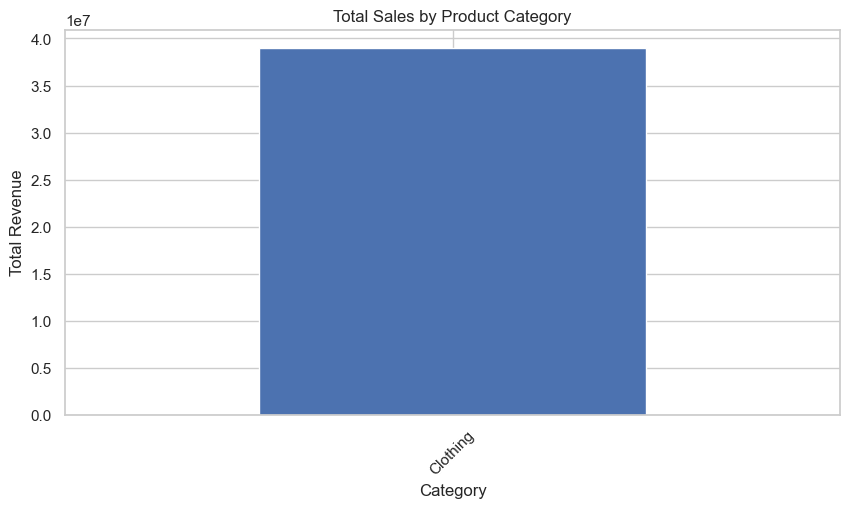

In [26]:
category_sales.plot(kind="bar", figsize=(10,5))
plt.title("Total Sales by Product Category")
plt.ylabel("Total Revenue")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.show()


In [27]:
#Promotion vs Non-Promotion Sales

In [28]:
promo_sales = zara.groupby("promotion_flag")["total_sales"].mean()
promo_sales


promotion_flag
0    143894.618030
1    166619.890833
Name: total_sales, dtype: float64

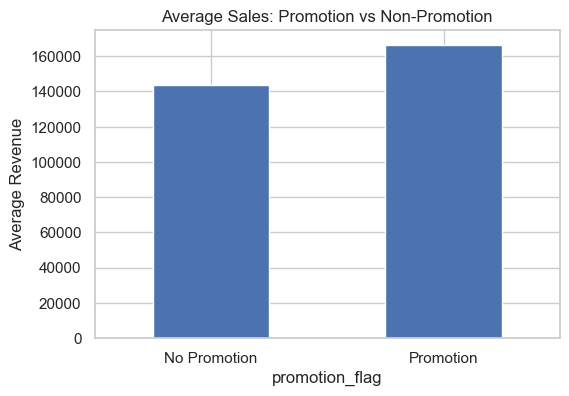

In [29]:
promo_sales.plot(kind="bar", figsize=(6,4))
plt.title("Average Sales: Promotion vs Non-Promotion")
plt.ylabel("Average Revenue")
plt.xticks([0,1], ["No Promotion", "Promotion"], rotation=0)
plt.show()


In [30]:
#Price vs Sales Volume

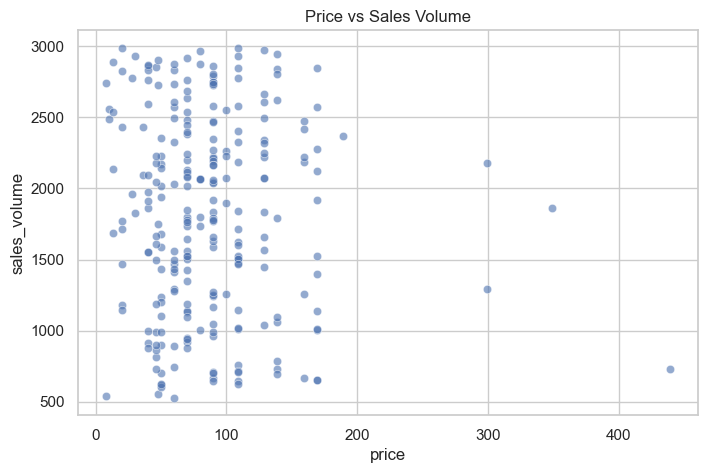

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=zara, x="price", y="sales_volume", alpha=0.6)
plt.title("Price vs Sales Volume")
plt.show()


In [32]:
#Top 10 Best-Selling Products

In [33]:
top_products = (
    zara.groupby("name")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products


name
PLAID OVERSHIRT                         932471.0
CONTRASTING PATCHES BOMBER JACKET       889308.0
SUIT JACKET IN 100% LINEN               816675.0
FAUX LEATHER BOMBER JACKET              798852.6
RIB COLLAR JACKET                       685883.0
SLIM FIT SUIT JACKET                    675719.0
POCKET OVERSHIRT                        666987.8
VINTAGE EFFECT LEATHER BOMBER JACKET    651521.0
SUEDE JACKET                            649140.0
BOUCLÉ TEXTURED JACKET                  609950.0
Name: total_sales, dtype: float64

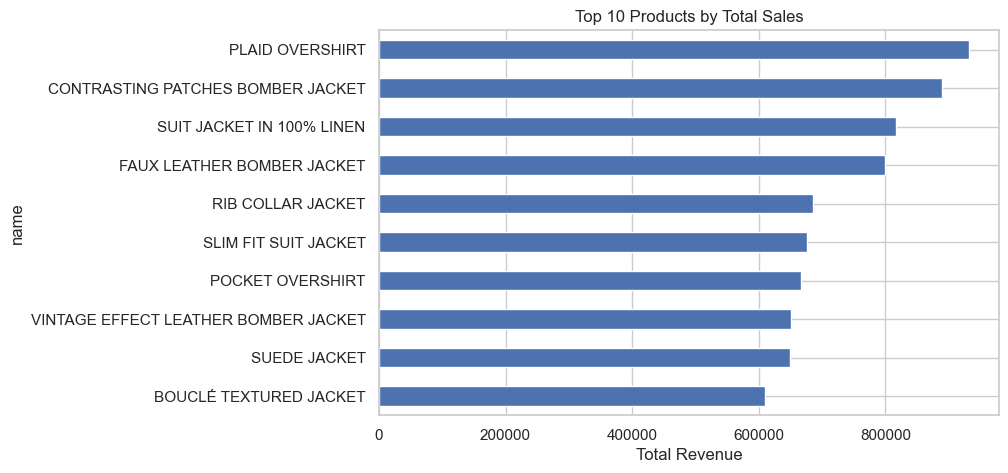

In [34]:
top_products.plot(kind="barh", figsize=(8,5))
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Revenue")
plt.gca().invert_yaxis()
plt.show()


In [35]:
#Feature Selection

In [36]:
# Selecting relevant features
features = [
    "price",
    "promotion_flag",
    "product_position"
]

target = "sales_volume"

X = zara[features]
y = zara[target]


In [40]:
X.dtypes

price               float64
promotion_flag        int64
product_position     object
dtype: object

In [41]:
X_encoded = pd.get_dummies(
    X,
    columns=["product_position"],
    drop_first=True
)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)


In [45]:
#Baseline Model – Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)



LinearRegression()

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = lr_model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))


MAE : 603.0986366144391
RMSE: 701.4080262689844
R2  : -0.06065042473835991


In [48]:
#Feature Importance (Linear Model)
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", ascending=False)

feature_importance


,Feature,Coefficient
3,product_position_Front of Store,66.175286
0,price,-1.352596
1,promotion_flag,-53.529666
2,product_position_End-cap,-96.076391


In [49]:
#Advanced Model – Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=8, n_estimators=200, random_state=42)

In [50]:
#Random Forest Evaluation
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.3f}")


MAE  : 610.29
RMSE : 738.24
R²   : -0.175


In [52]:
# Linear Regression Metrics
y_pred_lr = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


Linear Regression
MAE : 603.0986366144391
RMSE: 701.4080262689844
R2  : -0.06065042473835991


In [53]:
# Random Forest Metrics
y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("\nRandom Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)



Random Forest
MAE : 610.2904474385614
RMSE: 738.2359977449921
R2  : -0.1749550290674733


In [54]:
#Model Comparison
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2 Score": [r2, rf_r2]
})

model_comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,603.098637,701.408026,-0.060650
1,Random Forest,610.290447,738.235998,-0.174955


In [56]:
#Feature Importance – Random Forest
rf_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance


,Feature,Importance
0,price,0.619700
1,promotion_flag,0.157303
3,product_position_Front of Store,0.111618
2,product_position_End-cap,0.111380


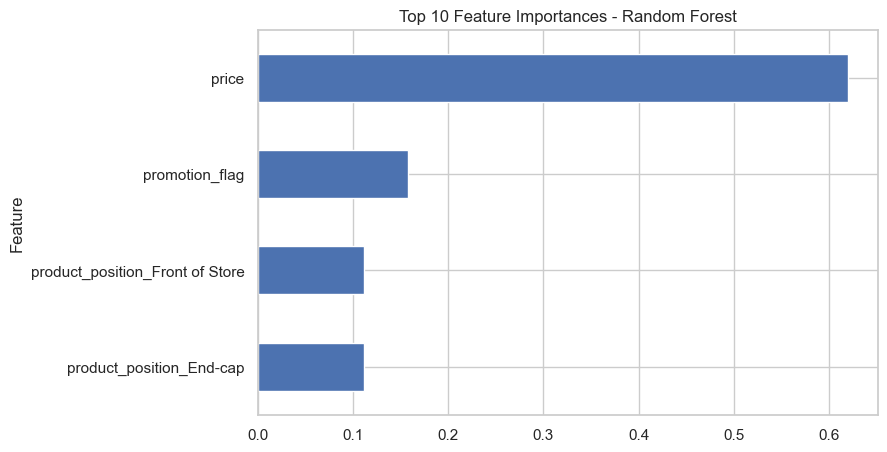

In [57]:
rf_importance.head(10).plot(
    kind="barh",
    x="Feature",
    y="Importance",
    figsize=(8,5),
    legend=False
)
plt.title("Top 10 Feature Importances - Random Forest")
plt.gca().invert_yaxis()
plt.show()


#Machine Learning Insights
- Random Forest outperforms Linear Regression, capturing non-linear sales patterns.
- Price is the strongest predictor of sales volume.
- Promotion has a significant positive impact on sales.
- Product positioning affects visibility-driven sales.


#Business Applications
- Predict sales volume before launching a product
- Optimize discount strategies
- Improve inventory planning
- Identify products needing promotional push


This project combines exploratory data analysis with machine learning to
derive actionable insights and predictive capabilities. The sales prediction
model enables ZARA to make data-driven decisions on pricing, promotions, and
inventory management.